# 04 — Reverse diffusion dynamics (Layer 4 / dynamics)

Convention: forward $dX=-X\,dt+\sqrt2\,dW$; reverse Euler-Maruyama
$x \leftarrow x + h(x+2s) + \sqrt{2h}\,\xi$ on a geometric time grid from $T=3$
to $t_{\min}=0.01$; probability-flow ODE $\dot x = -x - s$ with Heun steps.
Paired runs share initial noise and Brownian increments.

Rerun: `python experiments/exp_05_reverse_dynamics.py`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

OUT = Path("..") / "outputs"
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
def show(*names, exp):
    for n in names:
        display(Image(filename=str(OUT / exp / n)))


In [2]:
exp = "exp_05_reverse_dynamics"
pd.read_csv(OUT / exp / "setup1_terminal_stats.csv")

,sampler,innovation_excess_kurtosis,marginal_excess_kurtosis,marginal_var,lag1_corr
0,grid_bp_score,2.859,0.3976,1.065,0.8285
1,gaussian_bp_score,0.1197,-0.03233,1.051,0.8322
2,clean_prior_samples,2.718,0.4929,0.9354,0.8372


**Does the Gaussian score wash out non-Gaussian structure?** Compare the excess
kurtosis of fitted innovations $\hat\varepsilon_i = a_i - \rho a_{i-1}$ in reverse
samples against clean prior samples (Laplace innovations have excess kurtosis $+3$).

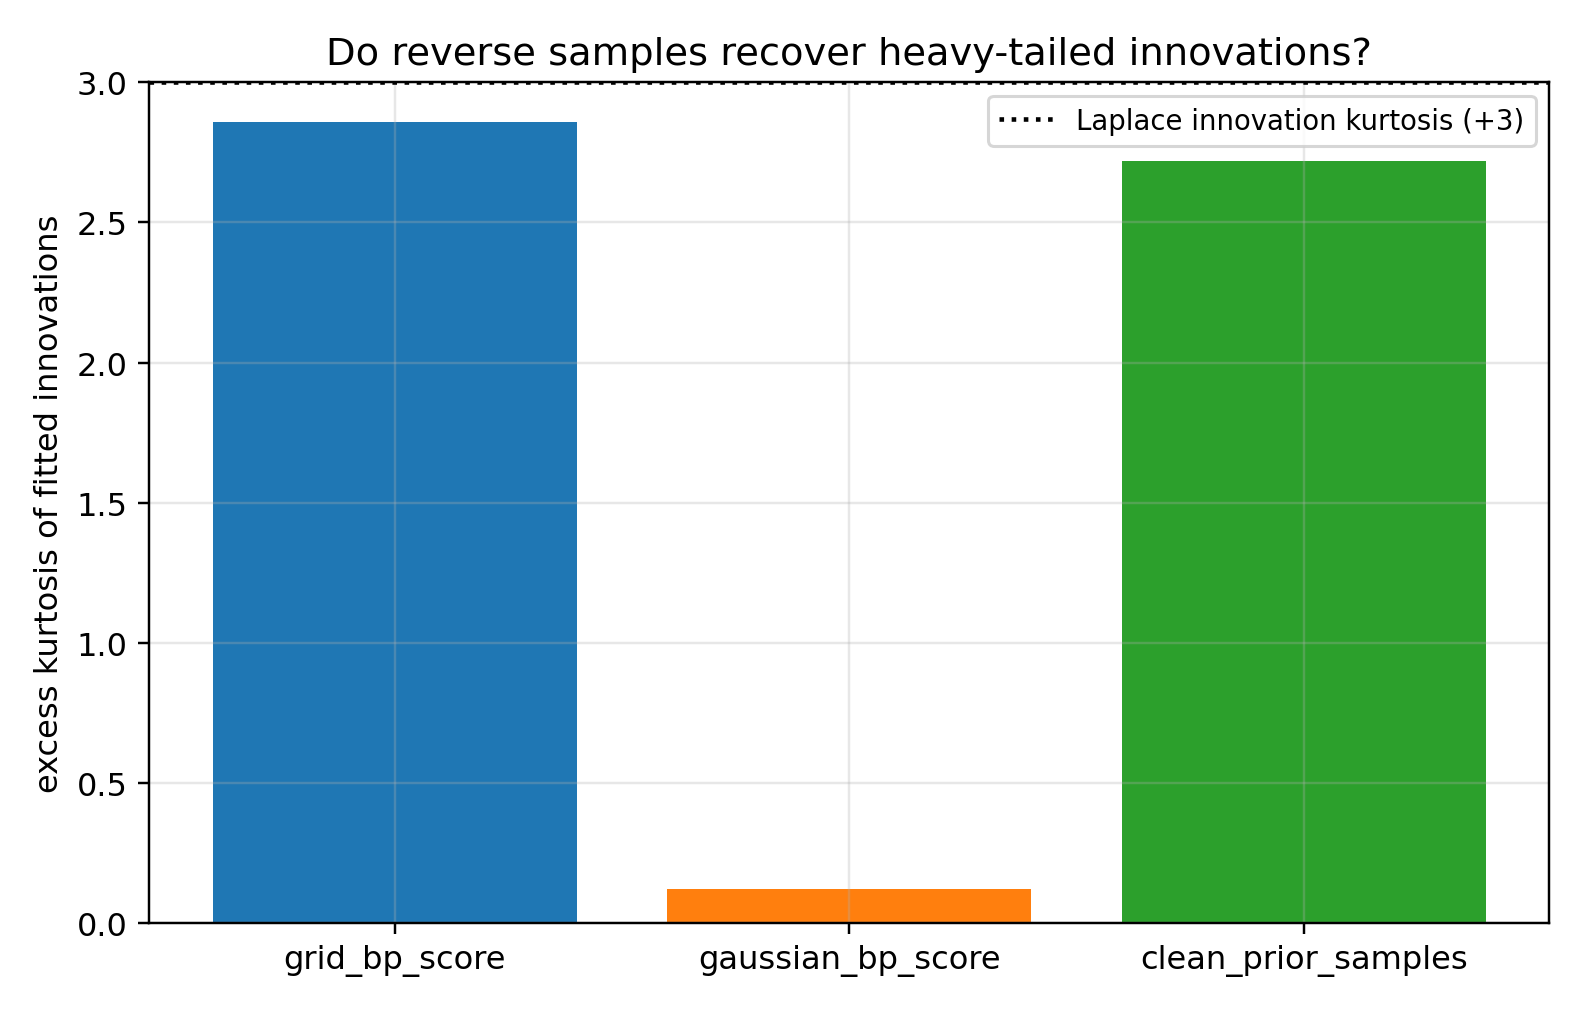

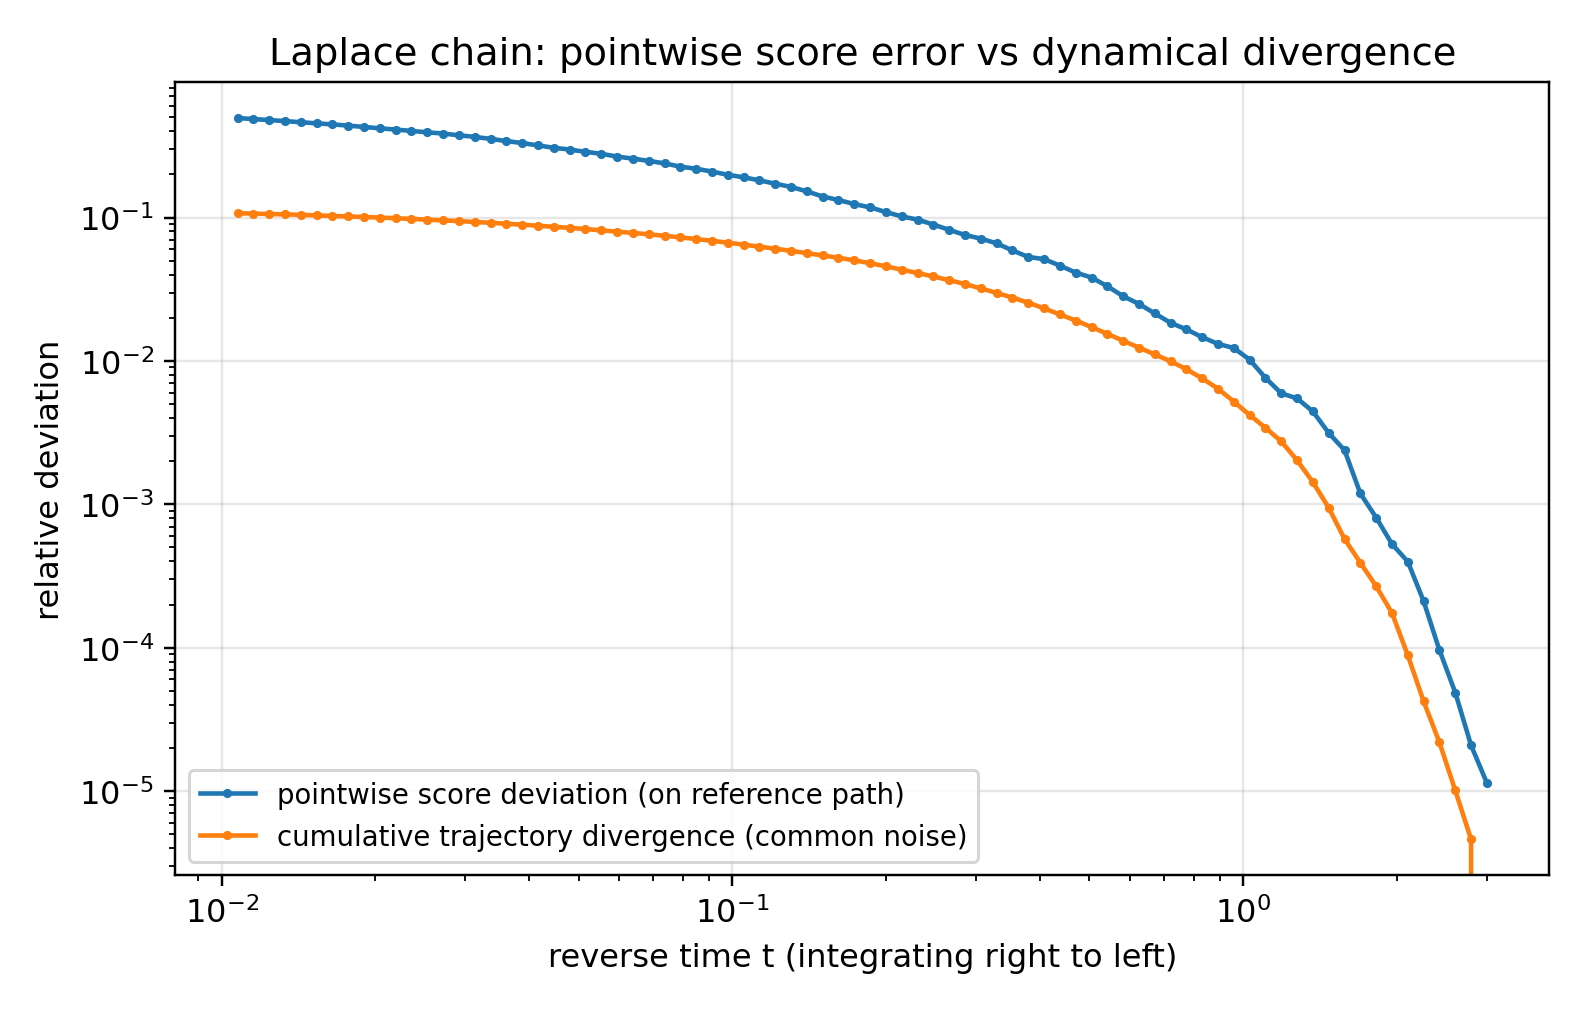

In [3]:
show("setup1_innovation_kurtosis.png", "setup1_pointwise_vs_dynamic.png", exp=exp)

In [4]:
div = pd.read_csv(OUT / exp / "setup1_divergence.csv")
div.tail(8)

,t,pointwise_rel_score_dev,trajectory_rel_divergence
72,0.01769,0.4376,0.1017
73,0.01647,0.4463,0.1026
74,0.01534,0.4539,0.1036
75,0.01428,0.4624,0.1044
76,0.0133,0.4708,0.1052
77,0.01238,0.4787,0.1059
78,0.01153,0.4865,0.1066
79,0.01074,0.4943,0.1072


## Reconstruction from t = 1

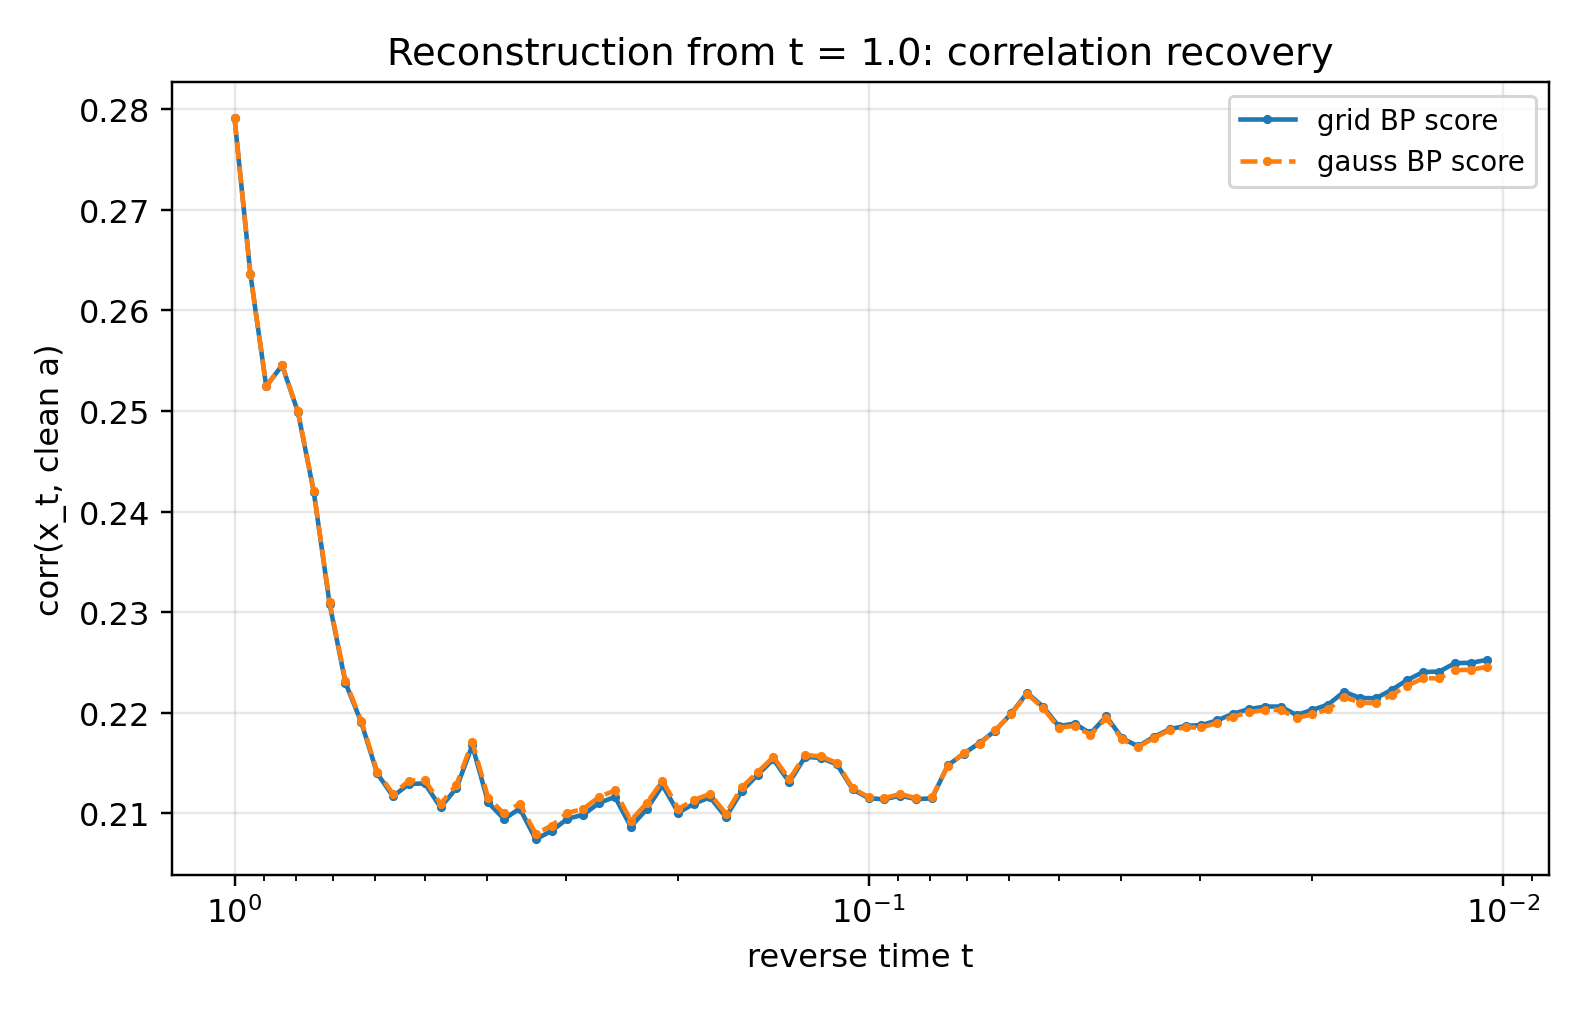

In [5]:
show("setup2_correlation_recovery.png", exp=exp)

## Model A: recovery of the global (non-Markov) mode

In [6]:
pd.read_csv(OUT / exp / "setup3_modelA_terminal.csv")

,sampler,top_eigenvalue,top_eigenvalue_true,cov_frobenius_rel_error,marginal_var
0,exact,10.49,12.68,0.2218,0.928
1,markov_chow_liu,8.137,12.68,0.368,0.9359
2,markov_naive,5.553,12.68,0.5295,0.7675
3,hybrid_rank_one,10.49,12.68,0.2218,0.928


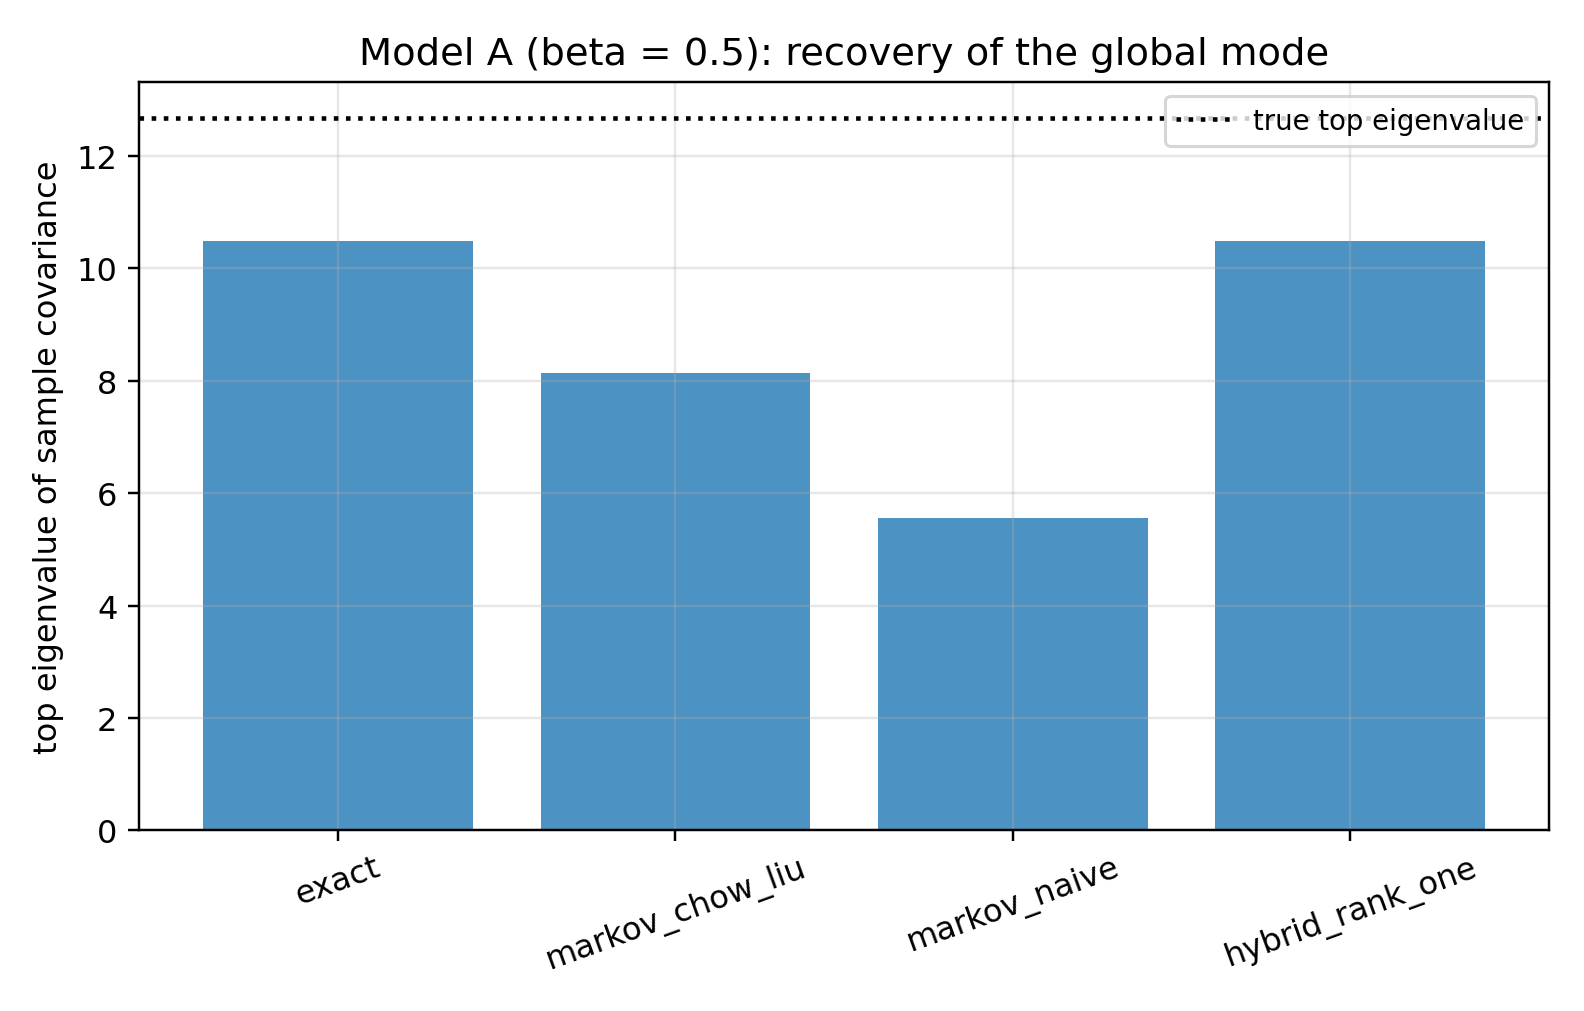

In [7]:
show("setup3_global_mode_recovery.png", exp=exp)